# Notebook 2: Logit Lens
**Kurs:** Mechanistic Interpretability  
**Modell:** EleutherAI/pythia-410m  
**Ziel:** Vorhersagen nach jeder Schicht visualisieren.

> **Aufgabe:** Implementiere die Zellen schrittweise. Hilfreiche Dokumentation:
> - HuggingFace `output_hidden_states`: https://huggingface.co/docs/transformers/main_classes/output#transformers.modeling_outputs.BaseModelOutputWithPast
> - PyTorch Softmax: https://pytorch.org/docs/stable/generated/torch.nn.functional.softmax.html
> - Matplotlib Imshow: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html

## Hintergrund: Was ist der Logit Lens?

Der **Logit Lens** (nostalgebraist, 2020) ist eine Technik, um zu sehen, was ein Transformer "nach jeder Schicht denkt".

**Kernidee:** Transformer haben einen **Residual Stream** — ein Informationskanal, der durch alle Schichten fließt. Jede Schicht *addiert* ihren Beitrag.

Da der finale Output die letzte Projektion des Residual Streams auf den Vokabular-Raum ist, können wir dieselbe **Unembed-Matrix W_U** auch auf frühere Hidden States anwenden:

```
Logit Lens bei Schicht L: logits_L = hidden_state_L @ W_U.T
```

So sehen wir, wie sich die Vorhersage über die Schichten herausbildet.

**Frage:** In welcher Schicht "weiß" das Modell die richtige Antwort?

## 1. Setup und Modell laden

In [ ]:
# TODO: Importiere torch, numpy, matplotlib
# TODO: Lade Tokenizer und Modell (wie in Notebook 1)
# 
# MODEL_NAME = "EleutherAI/pythia-410m"
# Fallback: MODEL_NAME = "gpt2-medium"  (bei gpt2-medium: model.lm_head.weight statt model.embed_out.weight)

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "EleutherAI/pythia-410m"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation="eager",
    torch_dtype=torch.float32
).to(device)

model.eval()

print("Model loaded successfully.")
print("Model type:", type(model).__name__)

Device: cpu


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Model loaded successfully.
Model type: GPTNeoXForCausalLM


## 2. Forward Pass mit Hidden States

In [35]:
PROMPT_FILE = Path("./sentiment_prompts.json")

with open(PROMPT_FILE, "r", encoding="utf-8") as f:
    prompt_data = json.load(f)

prompt_pairs = prompt_data["prompt_pairs"]
positive_target_tokens = prompt_data["target_tokens"]["positive"]
negative_target_tokens = prompt_data["target_tokens"]["negative"]

print("Number of prompt pairs:", len(prompt_pairs))
print("Positive target tokens:", positive_target_tokens)
print("Negative target tokens:", negative_target_tokens)

for pair in prompt_pairs:
    print()
    print("ID:", pair["id"])
    print("Clean:    ", pair["clean"])
    print("Corrupted:", pair["corrupted"])


# TODO: Tokenisiere beide Prompts
# TODO: Führe einen Forward Pass mit output_hidden_states=True durch
#
#   with torch.no_grad():
#       outputs = model(**inputs, output_hidden_states=True)
#
# TODO: Analysiere outputs.hidden_states:
#   - Wie viele Hidden States gibt es? (Tipp: num_layers + 1, Index 0 = Embedding)
#   - Was ist die Shape jedes Hidden State?
#
# Dokumentation: https://huggingface.co/docs/transformers/main_classes/output


clean_inputs = tokenizer(clean_prompt, return_tensors="pt").to(device)
corrupted_inputs = tokenizer(corrupted_prompt, return_tensors="pt").to(device)

with torch.no_grad():
    clean_outputs = model(
        **clean_inputs,
        output_hidden_states=True
    )

    corrupted_outputs = model(
        **corrupted_inputs,
        output_hidden_states=True
    )

clean_hidden_states = clean_outputs.hidden_states
corrupted_hidden_states = corrupted_outputs.hidden_states

print("Number of hidden states:", len(clean_hidden_states))
print("Expected: 25 because 24 layers + 1 embedding state")
print()

for i, hidden_state in enumerate(clean_hidden_states):
    print(f"Hidden state {i}: {hidden_state.shape}")

NameError: name 'json' is not defined

## 3. Logit Lens Funktion implementieren

In [ ]:
# Die Unembed-Matrix für Pythia:
#   unembed = model.embed_out.weight  # Shape: (vocab_size, hidden_size)
# Für GPT-2 Medium:
#   unembed = model.lm_head.weight

# TODO: Implementiere die Funktion logit_lens(hidden_state, top_k=5):
#   1. Nimm den Hidden State der LETZTEN Token-Position: hidden_state[0, -1, :]
#   2. Berechne die Logits: last_token_hs @ unembed.T
#   3. Wende Softmax an: torch.softmax(logits, dim=-1)
#   4. Berechne Top-K: torch.topk(probs, top_k)
#   5. Dekodiere die Token-IDs: tokenizer.decode([id])
#   6. Gib eine Liste von (token_string, probability) Tupeln zurück
#
# Hinweis: torch.Tensor.detach() löst den Tensor vom Berechnungsgraphen
# Hinweis: @ ist der Matrixmultiplikationsoperator in Python/PyTorch

# For Pythia models, the unembedding matrix is:
unembed = model.embed_out.weight

print("Unembed shape:", unembed.shape)
print("Expected shape: [vocab_size, hidden_size]")

def logit_lens(hidden_state, top_k=5):
    """
    Applies the model's unembedding matrix to an intermediate hidden state.

    Input:
        hidden_state: Tensor with shape [batch_size, sequence_length, hidden_size]

    Output:
        List of tuples:
        [(token_string, probability), ...]
    """

    # We only inspect the final token position.
    # Example:
    # "The capital of France is"
    # We want to know what the model predicts AFTER "is".
    last_token_hidden_state = hidden_state[0, -1, :]

    # Project hidden state into vocabulary space.
    # Shape:
    # [hidden_size] @ [hidden_size, vocab_size] = [vocab_size]
    logits = last_token_hidden_state @ unembed.T

    # Safety check
    if torch.isnan(logits).any():
        raise ValueError("NaN detected in logits. Check model dtype/device.")

    # Convert logits to probabilities
    probs = torch.softmax(logits.float(), dim=-1)

    # Get Top-K probabilities and token IDs
    top_probs, top_token_ids = torch.topk(probs, top_k)

    results = []

    for token_id, prob in zip(top_token_ids, top_probs):
        token_string = tokenizer.decode([token_id.item()])
        results.append(
            (token_string, prob.item())
        )

    return results

clean_final_results = logit_lens(clean_hidden_states[-1], top_k=5)

print(f"Prompt: {clean_prompt}")
print("-" * 60)

for rank, (token, prob) in enumerate(clean_final_results, start=1):
    print(f"{rank}. Token: {repr(token):15s} | Probability: {prob:.4f}")

Unembed shape: torch.Size([50304, 1024])
Expected shape: [vocab_size, hidden_size]
Prompt: The capital of France is
------------------------------------------------------------
1. Token: ' Paris'        | Probability: 0.1507
2. Token: ' Saint'        | Probability: 0.0621
3. Token: ' the'          | Probability: 0.0589
4. Token: ' in'           | Probability: 0.0504
5. Token: ' located'      | Probability: 0.0410


## 4. Logit Lens über alle Schichten berechnen

In [ ]:
# TODO: Iteriere über alle Hidden States (outputs.hidden_states)
#   und rufe logit_lens() für jeden auf.
#
# TODO: Speichere die Ergebnisse in einer Liste und gib eine Tabelle aus:
#   - Layer | Top-1 Token (Clean) | P(Clean) | Top-1 Token (Corrupt) | P(Corrupt)
#
# Frage: Ab welcher Schicht ist " Paris" unter den Top-1-Vorhersagen?


# ============================================================
# 4. Logit Lens über alle Schichten berechnen
# ============================================================

clean_results_all_layers = []
corrupted_results_all_layers = []

for layer_idx, hidden_state in enumerate(clean_hidden_states):
    results = logit_lens(hidden_state, top_k=5)
    clean_results_all_layers.append(results)

for layer_idx, hidden_state in enumerate(corrupted_hidden_states):
    results = logit_lens(hidden_state, top_k=5)
    corrupted_results_all_layers.append(results)


print(
    f"{'Layer':<8} | "
    f"{'Top-1 Clean':<15} | "
    f"{'P(Clean)':<10} | "
    f"{'Top-1 Corrupt':<15} | "
    f"{'P(Corrupt)':<10}"
)

print("-" * 75)

for layer_idx in range(len(clean_results_all_layers)):
    clean_top_token, clean_top_prob = clean_results_all_layers[layer_idx][0]
    corrupt_top_token, corrupt_top_prob = corrupted_results_all_layers[layer_idx][0]

    print(
        f"{layer_idx:<8} | "
        f"{repr(clean_top_token):<15} | "
        f"{clean_top_prob:<10.4f} | "
        f"{repr(corrupt_top_token):<15} | "
        f"{corrupt_top_prob:<10.4f}"
    )


# Prüfen, ab welcher Schicht " Paris" Top-1 ist

target_token = " Paris"

for layer_idx, results in enumerate(clean_results_all_layers):
    top1_token = results[0][0]

    if top1_token == target_token:
        print(f"{repr(target_token)} ist erstmals Top-1 in Schicht {layer_idx}.")
        break
else:
    print(f"{repr(target_token)} ist in keiner Schicht Top-1.")

# Prüfen, ab welcher Schicht " Paris" in den Top-5 ist

target_token = " Paris"

for layer_idx, results in enumerate(clean_results_all_layers):
    top5_tokens = [token for token, prob in results]

    if target_token in top5_tokens:
        print(f"{repr(target_token)} ist erstmals in den Top-5 in Schicht {layer_idx}.")
        break
else:
    print(f"{repr(target_token)} ist in keiner Schicht in den Top-5.")



Layer    | Top-1 Clean     | P(Clean)   | Top-1 Corrupt   | P(Corrupt)
---------------------------------------------------------------------------
0        | 'psis'          | 0.0000     | 'psis'          | 0.0000    
1        | 'INT'           | 0.0001     | 'eries'         | 0.0001    
2        | 'uckles'        | 0.0001     | 'PI'            | 0.0001    
3        | 'PI'            | 0.0001     | 'PI'            | 0.0002    
4        | ' either'       | 0.0001     | 'PI'            | 0.0001    
5        | ' either'       | 0.0001     | 'PI'            | 0.0001    
6        | ' either'       | 0.0001     | ' either'       | 0.0001    
7        | 'opan'          | 0.0001     | 'opan'          | 0.0001    
8        | ' therefore'    | 0.0001     | ' located'      | 0.0001    
9        | ' therefore'    | 0.0001     | ' located'      | 0.0002    
10       | ' only'         | 0.0001     | ' located'      | 0.0001    
11       | ' nat'          | 0.0001     | 'her'           | 0.0001    
1

## 5. Wahrscheinlichkeit des richtigen Tokens pro Schicht

Correct token: ' Paris'
Correct token ID: 7785
Decoded check:  Paris
Clean P(' Paris') per layer:
[1.986059214686975e-05, 2.3997670723474585e-05, 2.319517807336524e-05, 2.3345199224422686e-05, 2.291780947416555e-05, 1.836064075178001e-05, 2.248966666229535e-05, 2.0942194169037975e-05, 1.881644675449934e-05, 2.081812999676913e-05, 2.1575937353190966e-05, 2.143287747458089e-05, 2.1271564037306234e-05, 2.2776412151870318e-05, 3.287335130153224e-05, 3.884160105371848e-05, 4.410948167787865e-05, 0.00010164437117055058, 0.0026047113351523876, 0.004102662205696106, 0.006281123496592045, 0.008192257955670357, 0.0076801055110991, 0.0041425880044698715, 0.15070755779743195]

Corrupted P(' Paris') per layer:
[1.986059214686975e-05, 2.3059243176248856e-05, 2.391730777162593e-05, 2.4271057554869913e-05, 2.3120657715480775e-05, 1.863255056377966e-05, 2.3824690288165584e-05, 2.291647979291156e-05, 1.9286144379293546e-05, 2.1667376131517813e-05, 2.4877355826902203e-05, 2.440087337163277e-05, 2.2380894

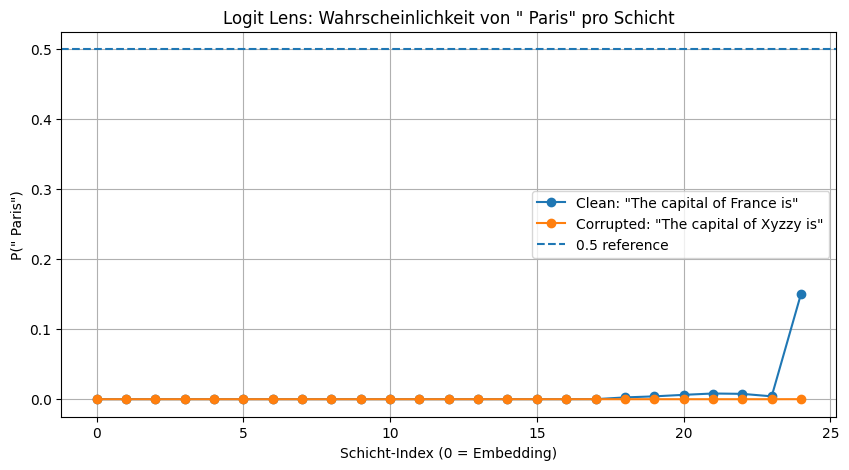

In [ ]:
# TODO: Implementiere get_token_prob_per_layer(outputs, token_id):
#   Gibt für jeden Layer die Wahrscheinlichkeit eines bestimmten Tokens zurück.
#
# correct_token = " Paris"
# correct_tok_id = tokenizer.encode(correct_token)[0]
#
# TODO: Rufe die Funktion für clean und corrupted auf.
# TODO: Erstelle einen Linienchart (plt.plot) mit:
#   - X-Achse: Schicht-Index (0 = Embedding)
#   - Y-Achse: P(" Paris")
#   - Eine Linie für clean, eine für corrupted
#   - Horizontale Linie bei 0.5 als Referenz
#
# Dokumentation plt.plot: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html

# ============================================================
# 5. Wahrscheinlichkeit des richtigen Tokens pro Schicht
# ============================================================

correct_token = " Paris"
correct_tok_id = tokenizer.encode(correct_token, add_special_tokens=False)[0]

print("Correct token:", repr(correct_token))
print("Correct token ID:", correct_tok_id)
print("Decoded check:", tokenizer.decode([correct_tok_id]))



def get_token_prob_per_layer(hidden_states, token_id):
    """
    Berechnet die Wahrscheinlichkeit eines bestimmten Tokens
    für jede Schicht mit Logit Lens.

    hidden_states:
        Tuple/List von Hidden States.
        Jeder Hidden State hat Shape:
        [batch_size, sequence_length, hidden_size]

    token_id:
        ID des Tokens, dessen Wahrscheinlichkeit untersucht wird.
    """

    probs_per_layer = []

    for hidden_state in hidden_states:
        last_token_hidden_state = hidden_state[0, -1, :]

        logits = last_token_hidden_state @ unembed.T

        if torch.isnan(logits).any():
            raise ValueError("NaN detected in logits. Reload model with torch.float32.")

        probs = torch.softmax(logits.float(), dim=-1)

        token_prob = probs[token_id].item()
        probs_per_layer.append(token_prob)

    return probs_per_layer

clean_paris_probs = get_token_prob_per_layer(
    clean_hidden_states,
    correct_tok_id
)

corrupted_paris_probs = get_token_prob_per_layer(
    corrupted_hidden_states,
    correct_tok_id
)

print("Clean P(' Paris') per layer:")
print(clean_paris_probs)

print("\nCorrupted P(' Paris') per layer:")
print(corrupted_paris_probs)


layers = list(range(len(clean_paris_probs)))

plt.figure(figsize=(10, 5))

plt.plot(
    layers,
    clean_paris_probs,
    marker="o",
    label='Clean: "The capital of France is"'
)

plt.plot(
    layers,
    corrupted_paris_probs,
    marker="o",
    label='Corrupted: "The capital of Xyzzy is"'
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="0.5 reference"
)

plt.xlabel("Schicht-Index (0 = Embedding)")
plt.ylabel('P(" Paris")')
plt.title('Logit Lens: Wahrscheinlichkeit von " Paris" pro Schicht')
plt.legend()
plt.grid(True)
plt.show()

## 6. Heatmap: Top-5 Token je Schicht

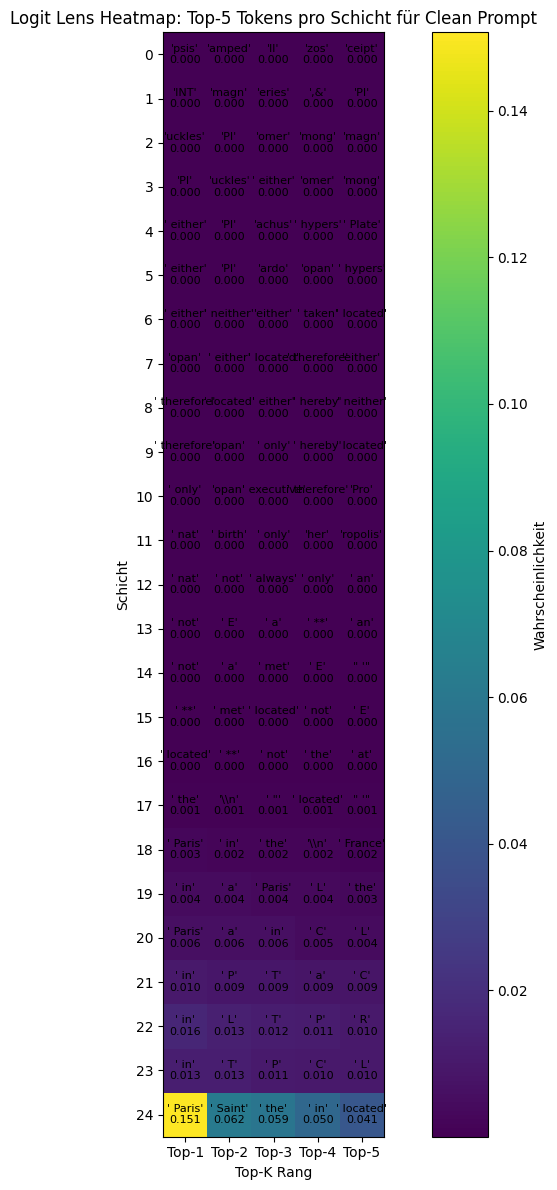

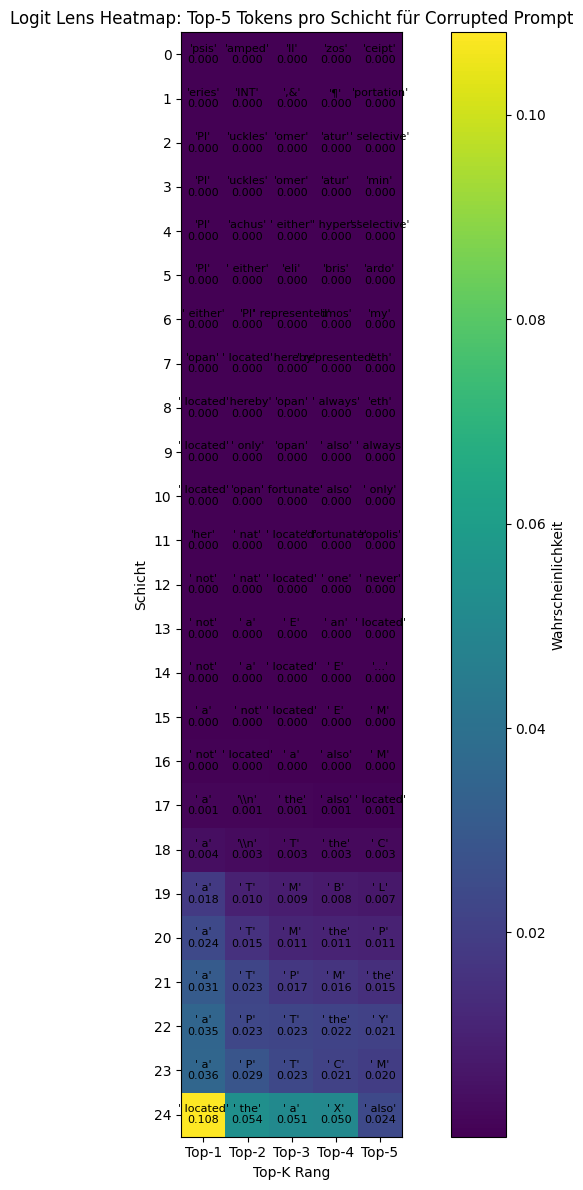

In [ ]:
# BONUS: Erstelle eine Heatmap mit plt.imshow():
#   - Y-Achse: Schichten (0 bis n_layers)
#   - X-Achse: Top-K Rang (0 bis 4)
#   - Farbe: Wahrscheinlichkeit des Tokens
#   - Text in jeder Zelle: Token-String (ax.text(...))
#
# Tipp: Erstelle zuerst eine Matrix (n_layers × top_k) mit Wahrscheinlichkeiten
# Tipp: plt.imshow(matrix, cmap="Blues") erstellt die Heatmap
#
# Dokumentation Imshow:
#   https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html

# ============================================================
# 6. Heatmap: Top-5 Token je Schicht
# ============================================================

top_k = 5

prob_matrix = []
token_matrix = []

for results in clean_results_all_layers:
    layer_probs = []
    layer_tokens = []

    for token, prob in results[:top_k]:
        layer_tokens.append(token)
        layer_probs.append(prob)

    token_matrix.append(layer_tokens)
    prob_matrix.append(layer_probs)

prob_matrix = np.array(prob_matrix)

fig, ax = plt.subplots(figsize=(10, 12))

im = ax.imshow(prob_matrix)

ax.set_xlabel("Top-K Rang")
ax.set_ylabel("Schicht")
ax.set_title('Logit Lens Heatmap: Top-5 Tokens pro Schicht für Clean Prompt')

ax.set_xticks(range(top_k))
ax.set_xticklabels([f"Top-{i+1}" for i in range(top_k)])

ax.set_yticks(range(len(prob_matrix)))
ax.set_yticklabels(range(len(prob_matrix)))

for i in range(prob_matrix.shape[0]):
    for j in range(prob_matrix.shape[1]):
        token_text = token_matrix[i][j].replace("\n", "\\n")

        ax.text(
            j,
            i,
            f"{repr(token_text)}\n{prob_matrix[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(im, ax=ax, label="Wahrscheinlichkeit")
plt.tight_layout()
plt.show()


top_k = 5

corrupt_prob_matrix = []
corrupt_token_matrix = []

for results in corrupted_results_all_layers:
    layer_probs = []
    layer_tokens = []

    for token, prob in results[:top_k]:
        layer_tokens.append(token)
        layer_probs.append(prob)

    corrupt_token_matrix.append(layer_tokens)
    corrupt_prob_matrix.append(layer_probs)

corrupt_prob_matrix = np.array(corrupt_prob_matrix)


fig, ax = plt.subplots(figsize=(10, 12))

im = ax.imshow(corrupt_prob_matrix)

ax.set_xlabel("Top-K Rang")
ax.set_ylabel("Schicht")
ax.set_title('Logit Lens Heatmap: Top-5 Tokens pro Schicht für Corrupted Prompt')

ax.set_xticks(range(top_k))
ax.set_xticklabels([f"Top-{i+1}" for i in range(top_k)])

ax.set_yticks(range(len(corrupt_prob_matrix)))
ax.set_yticklabels(range(len(corrupt_prob_matrix)))

for i in range(corrupt_prob_matrix.shape[0]):
    for j in range(corrupt_prob_matrix.shape[1]):
        token_text = corrupt_token_matrix[i][j].replace("\n", "\\n")

        ax.text(
            j,
            i,
            f"{repr(token_text)}\n{corrupt_prob_matrix[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(im, ax=ax, label="Wahrscheinlichkeit")
plt.tight_layout()
plt.show()

## 7. Reflexionsfragen

In [ ]:
# Beantworte folgende Fragen als Kommentare oder Markdown-Zellen:
#
# 1. In welcher Schicht taucht " Paris" erstmals in den Top-5 auf (Clean)?
# 2. Was passiert bei den frühen Schichten (0-3)?
# 3. Warum bleibt P(" Paris") für den Corrupted-Prompt durchgehend niedrig?
# 4. Was zeigt uns der Logit Lens über den Residual Stream?
#
# Hinweis: Es gibt keine "richtige" Antwort — beschreibe, was du beobachtest.